# SkyPose — Train model Pose Estimation trên Kaggle (chạy code từ GitHub)

Notebook này **không chứa code model**: nó clone repo đồ án từ GitHub rồi gọi đúng các script
trong `training/` (giống hệt khi chạy ở máy local):

| Bước | Script trong repo | Log |
|---|---|---|
| Cắt vùng người từ COCO | `training/prepare_data.py` | `logs/02_prepare_val.log`, `logs/03_prepare_train.log` |
| Huấn luyện SimpleBaseline | `training/train.py` | `logs/04_train.log` + `<backbone>/train.log`, `train_log.csv` |
| Đánh giá COCO AP / PCK / tốc độ | `training/evaluate.py` | `logs/05_evaluate.log`, `eval_<backbone>.json` |
| Biểu đồ cho báo cáo | `training/make_figures.py` | `logs/06_figures.log`, `figures/` |

Mọi log được ghi **liên tục** vào `/kaggle/working/out/` (tab **Output**) nên vẫn tải về được
kể cả khi một bước bị lỗi. `run_info.json` ghi lại commit, cấu hình, GPU, thời gian và trạng thái
từng bước. Cuối notebook đóng gói tất cả vào `out/skypose_<backbone>_<thời gian>.zip`.

### Cài đặt trên Kaggle trước khi chạy
1. **Settings → Accelerator:** `GPU T4 x2` (hoặc `GPU P100`).
2. **Settings → Internet:** `On` (clone GitHub + tải trọng số ImageNet).
3. *(Khuyến nghị)* **Add Input** → dataset **COCO 2017** (vd. `awsaf49/coco-2017-dataset`).
   Không gắn thì script tự tải ảnh từ `images.cocodataset.org` (chậm hơn).
4. Sửa `REPO_URL` ở ô cấu hình → **Save Version → Save & Run All (Commit)**.

**Repo private?** Tạo GitHub token (quyền đọc repo) → Kaggle **Add-ons → Secrets** thêm
secret tên `GITHUB_TOKEN` và bật cho notebook này.

**Lưu trữ ở máy local:** tải file zip trong tab Output rồi chạy
`python scripts/import_kaggle_run.py <file.zip>` → giải nén vào `runs/<tên lần chạy>/`.

## 1. Cấu hình

In [1]:
import os
from datetime import datetime
from pathlib import Path

ON_KAGGLE = Path("/kaggle").exists()

REPO_URL = os.environ.get("SKYPOSE_REPO_URL", "https://github.com/SGU-ML25/PatternRecognition.git")
BRANCH = "main"

BACKBONE = "resnet18"     # "resnet18" (mặc định: nhẹ, nhanh, đủ chính xác cho game) | "resnet34" | "resnet50"
EPOCHS = 20              # resnet18 trên T4 x2: ~15-18 phút/epoch (thường nghẽn ở 4 CPU nạp dữ liệu)
BATCH_SIZE = 128         # tổng batch (DataParallel tự chia cho 2 GPU)
RESUME_FROM = None        # vd. "/kaggle/input/skypose-ckpt/last.pt" để train tiếp
SMOKE_TEST = not ON_KAGGLE  # chạy thử vài phút khi không ở trên Kaggle

BASE = Path("/kaggle/working") if ON_KAGGLE else Path(os.environ.get("SKYPOSE_SMOKE_DIR", "/tmp/skypose_smoke"))
REPO = BASE / "repo"                                     # mã nguồn clone về
OUT = BASE / "out"                                       # kết quả + log (lưu trong Output của Kaggle)
LOGS = OUT / "logs"
CROPS = Path("/tmp/skypose_crops") if ON_KAGGLE else BASE / "crops"   # crop tạm, không cần lưu
LOGS.mkdir(parents=True, exist_ok=True)
if SMOKE_TEST:
    BACKBONE, EPOCHS, BATCH_SIZE = "resnet18", 1, 16
RUN_NAME = f"{datetime.now():%Y%m%d-%H%M}_{BACKBONE}_{'kaggle' if ON_KAGGLE else 'local'}"
print(f"Lần chạy: {RUN_NAME} | smoke={SMOKE_TEST} | {BACKBONE} {EPOCHS} epoch, batch {BATCH_SIZE}")

Lần chạy: 20261002-1405_resnet18_kaggle | smoke=False | resnet18 20 epoch, batch 128


## 2. Ghi log + thông tin lần chạy

In [2]:
import json
import platform
import re
import shutil
import subprocess
import sys
import time

RUN_INFO = OUT / "run_info.json"
info = {
    "run_name": RUN_NAME, "started": datetime.now().isoformat(timespec="seconds"), "status": "running",
    "platform": "kaggle" if ON_KAGGLE else "local", "python": platform.python_version(),
    "config": {"repo_url": REPO_URL, "branch": BRANCH, "backbone": BACKBONE, "epochs": EPOCHS,
               "batch_size": BATCH_SIZE, "resume_from": RESUME_FROM, "smoke_test": SMOKE_TEST},
    "steps": [],
}
SECRETS = []  # chuỗi cần che trong log (token GitHub)


def mask(text):
    for s in SECRETS:
        text = text.replace(s, "***")
    return text


def save_info():
    RUN_INFO.write_text(json.dumps(info, indent=2, ensure_ascii=False))


def run(step, cmd, cwd=None, extra_log=None):
    """Chạy lệnh; in trực tiếp + ghi vào logs/<step>.log. Trả về True nếu thành công."""
    log_path = LOGS / f"{step}.log"
    cmd = list(map(str, cmd))
    t0 = time.time()
    rec = {"step": step, "cmd": mask(" ".join(cmd)), "log": f"logs/{log_path.name}",
           "started": datetime.now().isoformat(timespec="seconds")}
    info["steps"].append(rec); save_info()
    with open(log_path, "a") as log:
        log.write(f"$ {rec['cmd']}\n")
        print(f"$ {rec['cmd']}", flush=True)
        p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
                             cwd=cwd, env=os.environ.copy())
        for line in p.stdout:
            line = mask(line)
            print(line, end="", flush=True)
            log.write(line); log.flush()
        code = p.wait()
    rec.update(exit_code=code, minutes=round((time.time() - t0) / 60, 2), ok=code == 0)
    save_info()
    if code != 0:
        print(f"!! Bước {step} lỗi (exit {code}) — xem {log_path}")
    return code == 0


OK = True  # các bước sau chỉ chạy khi bước trước thành công
save_info()

## 3. Clone repo + cài thư viện

In [3]:
url = REPO_URL
if ON_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret("GITHUB_TOKEN")
        SECRETS.append(token)
        url = REPO_URL.replace("https://", f"https://{token}@")
        print("Dùng GITHUB_TOKEN từ Kaggle Secrets (repo private)")
    except Exception:
        pass  # repo public
if REPO.exists():
    shutil.rmtree(REPO)
OK = run("01_setup", ["git", "clone", "--depth", "1", "--branch", BRANCH, url, REPO])
if OK:
    commit = subprocess.run(["git", "-C", REPO, "log", "-1", "--format=%H|%s|%cI"],
                            capture_output=True, text=True).stdout.strip().split("|")
    info["git"] = {"commit": commit[0], "message": commit[1], "date": commit[2]}
    print("commit:", " | ".join(commit))
    OK = run("01_setup", [sys.executable, "-m", "pip", "install", "-q", "-r", REPO / "requirements-train.txt"])
env = subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout if shutil.which("nvidia-smi") else "no GPU"
(LOGS / "00_environment.log").write_text(env)
try:
    import torch
    info["torch"] = torch.__version__
    info["gpus"] = [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]
except ImportError:
    pass
save_info()
print("GPU:", info.get("gpus"))
TRAIN = REPO / "training"

$ git clone --depth 1 --branch main https://github.com/SGU-ML25/PatternRecognition.git /kaggle/working/repo
Cloning into '/kaggle/working/repo'...
commit: c142438d74900f21c0bdf6d3a35887d1cbeab6f1 | update resnet18 | 2026-10-02T21:03:54+07:00
$ /usr/bin/python3 -m pip install -q -r /kaggle/working/repo/requirements-train.txt
GPU: ['Tesla T4', 'Tesla T4']


## 4. Tìm dataset COCO-Keypoints 2017
Đường dẫn được truyền cho code qua biến môi trường (xem `training/paths.py`):
`SKYPOSE_ANN_DIR` (annotation) và `SKYPOSE_CROPS` (nơi ghi crop).

In [4]:
import urllib.request
import zipfile


def find_coco(root):
    """Quét /kaggle/input (giới hạn độ sâu, không đi vào thư mục ảnh) tìm annotation + ảnh."""
    ann = train_img = val_img = None
    if not root.exists():
        return ann, train_img, val_img
    for dirpath, dirnames, filenames in os.walk(root):
        d = Path(dirpath)
        if len(d.relative_to(root).parts) > 6:
            dirnames[:] = []
            continue
        if "person_keypoints_train2017.json" in filenames and ann is None:
            ann = d
        for name in ("train2017", "val2017"):
            if name in dirnames and next((d / name).glob("*.jpg"), None) is not None:
                if name == "train2017" and train_img is None:
                    train_img = d / name
                if name == "val2017" and val_img is None:
                    val_img = d / name
        dirnames[:] = [x for x in dirnames if x not in ("train2017", "val2017", "test2017", "unlabeled2017")]
    return ann, train_img, val_img


search_root = Path("/kaggle/input") if ON_KAGGLE else Path(os.environ.get("SKYPOSE_LOCAL_COCO", "data/coco")).resolve()
ANN_DIR, TRAIN_IMAGES, VAL_IMAGES = find_coco(search_root)
if ANN_DIR is None:
    zpath = BASE / "ann.zip"
    print("Không thấy annotation -> tải từ cocodataset.org")
    urllib.request.urlretrieve("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", zpath)
    with zipfile.ZipFile(zpath) as zf:
        for n in zf.namelist():
            if "person_keypoints" in n:
                zf.extract(n, BASE)
    zpath.unlink()
    ANN_DIR = BASE / "annotations"

os.environ["SKYPOSE_ANN_DIR"] = str(ANN_DIR)
os.environ["SKYPOSE_CROPS"] = str(CROPS)
info["data"] = {"annotations": str(ANN_DIR), "train_images": str(TRAIN_IMAGES or "images.cocodataset.org"),
                "val_images": str(VAL_IMAGES or "images.cocodataset.org"), "crops": str(CROPS)}
save_info()
print(json.dumps(info["data"], indent=2))

Không thấy annotation -> tải từ cocodataset.org
{
  "annotations": "/kaggle/working/annotations",
  "train_images": "images.cocodataset.org",
  "val_images": "images.cocodataset.org",
  "crops": "/tmp/skypose_crops"
}


## 5. Chuẩn bị dữ liệu — `training/prepare_data.py`

In [5]:
for step, split, images in (("02_prepare_val", "val", VAL_IMAGES), ("03_prepare_train", "train", TRAIN_IMAGES)):
    if not OK:
        break
    if (CROPS / f"{split}_index.npz").exists():
        print(f"{split}: đã có, bỏ qua")
        continue
    cmd = [sys.executable, TRAIN / "prepare_data.py", "--split", split, "--workers", 16 if images else 64]
    if images:
        cmd += ["--images-dir", images]
    if SMOKE_TEST:
        cmd += ["--limit-images", 150 if split == "train" else 200]
    OK = run(step, cmd)

$ /usr/bin/python3 /kaggle/working/repo/training/prepare_data.py --split val --workers 64
val: 6352 người / 2346 ảnh, nguồn ảnh: images.cocodataset.org
  1000/2346 ảnh, 2654 crop
  2000/2346 ảnh, 5161 crop
Xong: 6352 crop -> /tmp/skypose_crops/val_index.npz
$ /usr/bin/python3 /kaggle/working/repo/training/prepare_data.py --split train --workers 64
train: 127392 người / 52310 ảnh, nguồn ảnh: images.cocodataset.org
  1000/52310 ảnh, 1984 crop
  2000/52310 ảnh, 4435 crop
  3000/52310 ảnh, 6764 crop
  4000/52310 ảnh, 9085 crop
  5000/52310 ảnh, 11341 crop
  6000/52310 ảnh, 14424 crop
  7000/52310 ảnh, 16699 crop
  8000/52310 ảnh, 19525 crop
  9000/52310 ảnh, 21344 crop
  10000/52310 ảnh, 24030 crop
  11000/52310 ảnh, 26016 crop
  12000/52310 ảnh, 28084 crop
  13000/52310 ảnh, 30899 crop
  14000/52310 ảnh, 33881 crop
  15000/52310 ảnh, 36055 crop
  16000/52310 ảnh, 38544 crop
  17000/52310 ảnh, 40742 crop
  18000/52310 ảnh, 42904 crop
  19000/52310 ảnh, 45092 crop
  20000/52310 ảnh, 47238 c

## 6. Huấn luyện — `training/train.py`
`train.py` tự ghi `out/<backbone>/train.log` (có thời gian) và `train_log.csv` (mỗi epoch 1 dòng);
notebook ghi thêm toàn bộ output vào `logs/04_train.log`.

In [6]:
CKPT_DIR = OUT / BACKBONE
if OK:
    cmd = [sys.executable, TRAIN / "train.py", "--backbone", BACKBONE, "--epochs", EPOCHS,
           "--bs", BATCH_SIZE, "--out", CKPT_DIR]
    if RESUME_FROM:
        cmd += ["--resume-from", RESUME_FROM]
    elif (CKPT_DIR / "last.pt").exists():
        cmd += ["--resume"]
    if SMOKE_TEST:
        cmd += ["--limit", 320, "--eval-limit", 200]
    OK = run("04_train", cmd)

$ /usr/bin/python3 /kaggle/working/repo/training/train.py --backbone resnet18 --epochs 20 --bs 128 --out /kaggle/working/out/resnet18
===== Bắt đầu: /kaggle/working/repo/training/train.py --backbone resnet18 --epochs 20 --bs 128 --out /kaggle/working/out/resnet18
config: {'backbone': 'resnet18', 'epochs': 20, 'bs': 128, 'lr': 0.001, 'workers': 4, 'limit': 0, 'eval_limit': 0, 'out': '/kaggle/working/out/resnet18', 'resume': False, 'resume_from': None}
torch 2.10.0+cu128 | GPU: ['Tesla T4', 'Tesla T4']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth

  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 19%|█▉        | 8.38M/44.7M [00:00<00:00, 87.4MB/s]
 68%|██████▊   | 30.4M/44.7M [00:00<00:00, 171MB/s] 
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]
DataParallel trên 2 GPU
resnet18: 127392 mẫu train, 995 iter/epoch, 6352 mẫu val
ep 1 it 0/995 loss 0.001038 lr 2.01e-06 10 img/s
ep 1 it 200/995 loss 0.00083

## 7. Đánh giá cuối trên `best.pt` — `training/evaluate.py`

In [7]:
EVAL_JSON = OUT / f"eval_{BACKBONE}.json"
if OK:
    OK = run("05_evaluate", [sys.executable, TRAIN / "evaluate.py", "--ckpt", CKPT_DIR / "best.pt", "--out", EVAL_JSON])

$ /usr/bin/python3 /kaggle/working/repo/training/evaluate.py --ckpt /kaggle/working/out/resnet18/best.pt --out /kaggle/working/out/eval_resnet18.json
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower 

## 8. Biểu đồ — `training/make_figures.py`

$ /usr/bin/python3 /kaggle/working/repo/training/make_figures.py --run resnet18:/kaggle/working/out/resnet18/train.log:/kaggle/working/out/resnet18/train_log.csv --eval /kaggle/working/out/eval_resnet18.json --fig-dir /kaggle/working/out/figures
  -> /kaggle/working/out/figures/train_loss.png
  -> /kaggle/working/out/figures/val_ap.png
  -> /kaggle/working/out/figures/val_ap_breakdown.png
  -> /kaggle/working/out/figures/lr.png
  -> /kaggle/working/out/figures/pck_per_joint.png
  -> /kaggle/working/out/figures/pck_curve.png
lr.png


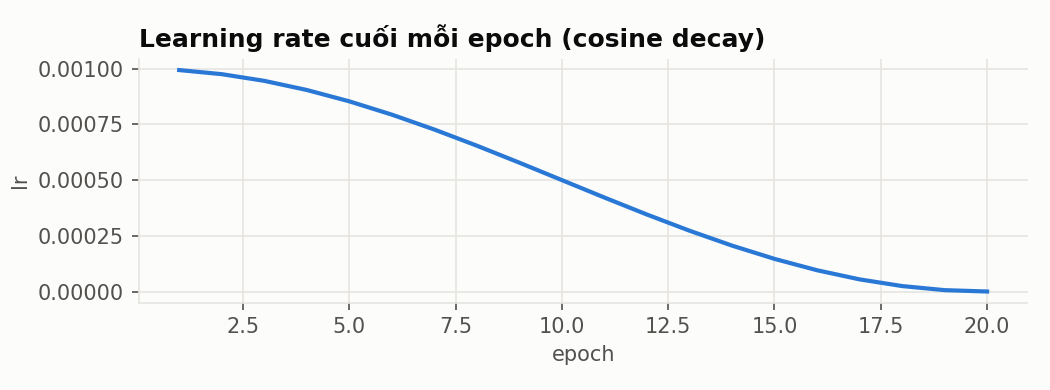

pck_curve.png


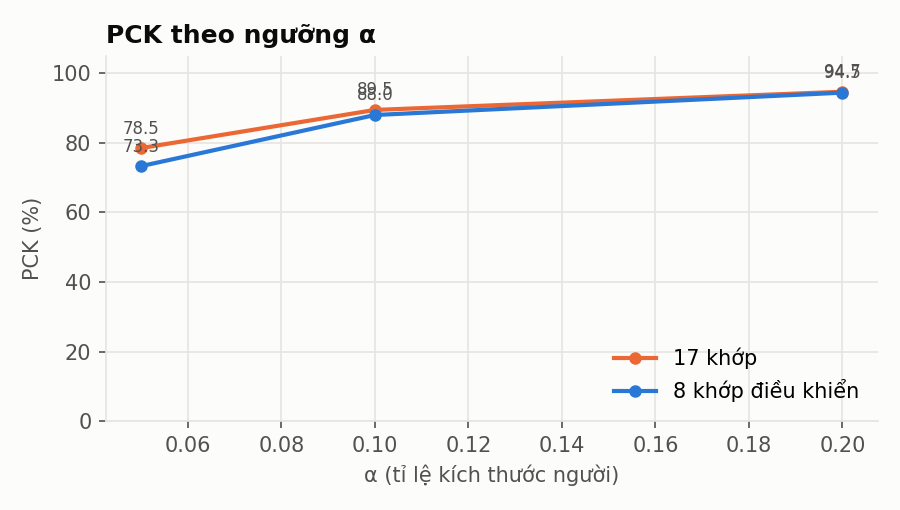

pck_per_joint.png


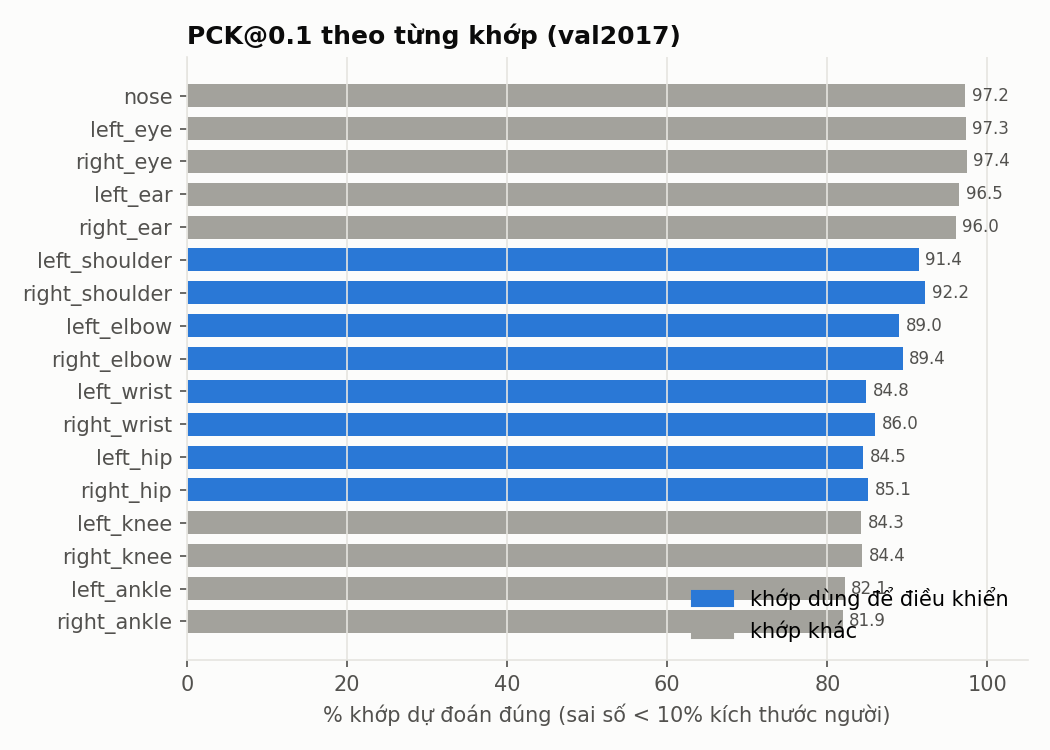

train_loss.png


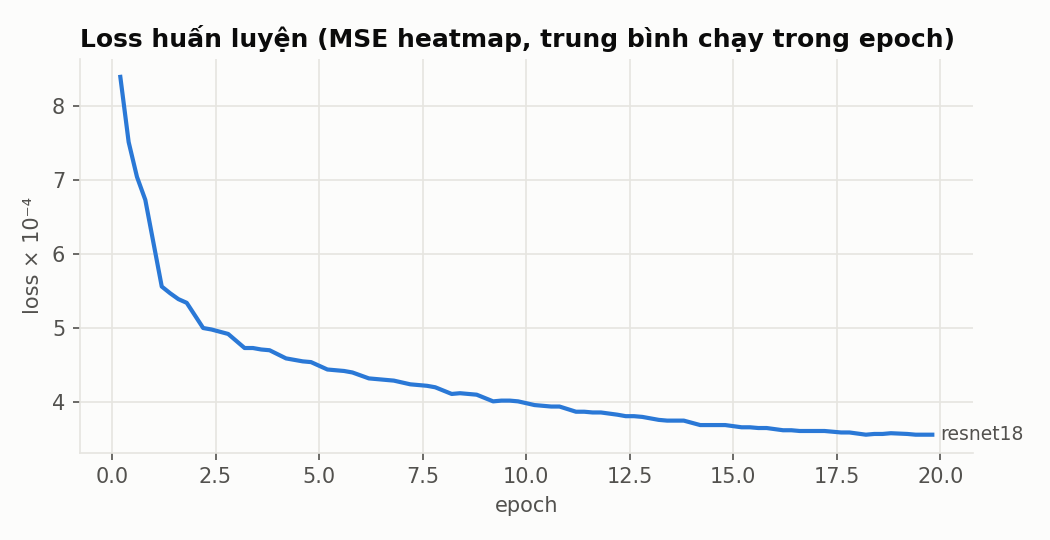

val_ap.png


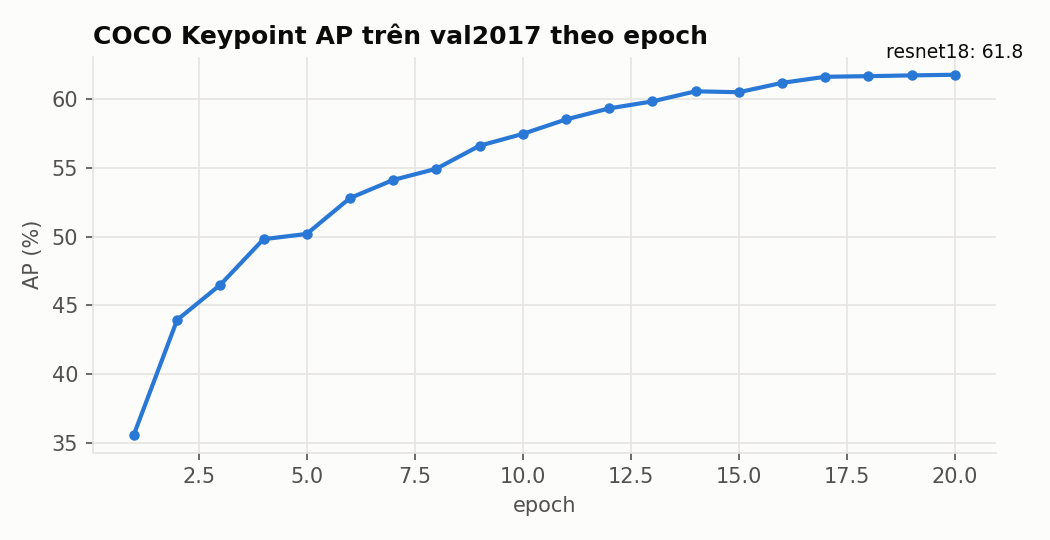

val_ap_breakdown.png


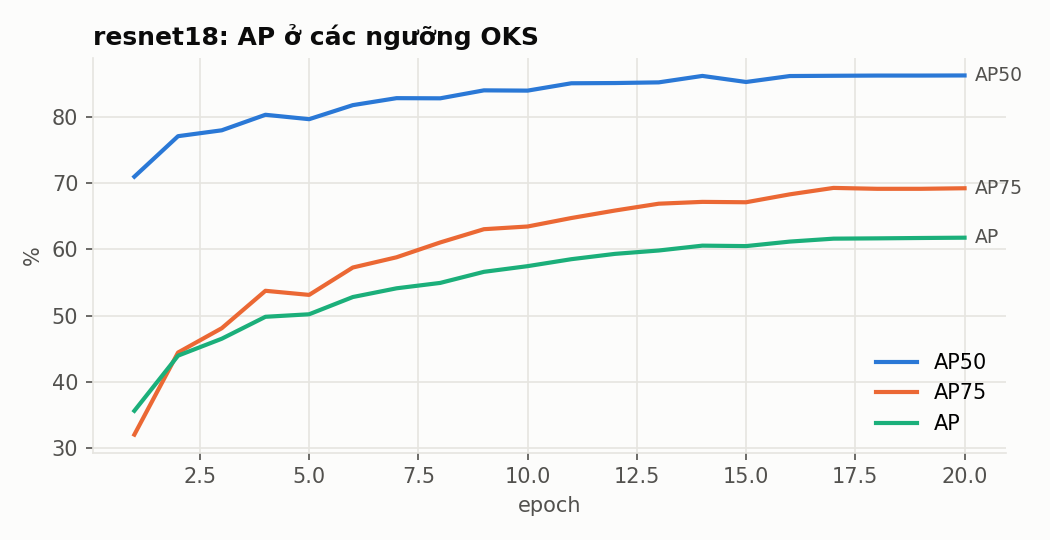

In [8]:
FIG_DIR = OUT / "figures"
if OK:
    cmd = [sys.executable, TRAIN / "make_figures.py",
           "--run", f"{BACKBONE}:{CKPT_DIR / 'train.log'}:{CKPT_DIR / 'train_log.csv'}",
           "--eval", EVAL_JSON, "--fig-dir", FIG_DIR]
    if VAL_IMAGES:
        cmd += ["--ckpt", CKPT_DIR / "best.pt", "--val-images", VAL_IMAGES]
    OK = run("06_figures", cmd, cwd=REPO)
    try:
        from IPython.display import Image, display
        for f in sorted(FIG_DIR.iterdir()):
            print(f.name)
            display(Image(filename=str(f), width=720))
    except Exception:
        pass

## 9. Đóng gói kết quả + log (luôn chạy, kể cả khi bước trước lỗi)
Tải `out/skypose_<...>.zip` trong tab **Output**. Bên trong:

| File | Nội dung |
|---|---|
| `best.pt` | model tốt nhất (dùng cho server game) |
| `run_info.json` | commit, cấu hình, GPU, thời gian + trạng thái từng bước |
| `logs/*.log` | output đầy đủ của từng bước |
| `<backbone>/train.log`, `<backbone>/train_log.csv` | log train có thời gian + chỉ số mỗi epoch |
| `eval_<backbone>.json`, `figures/` | kết quả đánh giá + biểu đồ |

`last.pt` (kèm optimizer, để train tiếp) không cho vào zip vì nặng — vẫn nằm trong `out/<backbone>/`.

In [9]:
info["status"] = "success" if OK else "failed"
info["finished"] = datetime.now().isoformat(timespec="seconds")
save_info()
zip_path = OUT / f"skypose_{RUN_NAME}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.rglob("*")):
        if p.is_file() and p.suffix != ".zip" and p.name != "last.pt":
            z.write(p, f"{RUN_NAME}/{p.relative_to(OUT)}")
print(f"{zip_path} ({zip_path.stat().st_size / 1e6:.1f} MB)")
with zipfile.ZipFile(zip_path) as z:
    for n in z.namelist():
        print("  ", n)
if ON_KAGGLE:
    shutil.rmtree(REPO, ignore_errors=True)  # không cần lưu mã nguồn trong Output
if not OK:
    raise RuntimeError("Có bước bị lỗi — xem run_info.json và logs/ trong file zip")

/kaggle/working/out/skypose_20261002-1405_resnet18_kaggle.zip (57.4 MB)
   20261002-1405_resnet18_kaggle/eval_resnet18.json
   20261002-1405_resnet18_kaggle/figures/lr.png
   20261002-1405_resnet18_kaggle/figures/pck_curve.png
   20261002-1405_resnet18_kaggle/figures/pck_per_joint.png
   20261002-1405_resnet18_kaggle/figures/train_loss.png
   20261002-1405_resnet18_kaggle/figures/val_ap.png
   20261002-1405_resnet18_kaggle/figures/val_ap_breakdown.png
   20261002-1405_resnet18_kaggle/logs/00_environment.log
   20261002-1405_resnet18_kaggle/logs/01_setup.log
   20261002-1405_resnet18_kaggle/logs/02_prepare_val.log
   20261002-1405_resnet18_kaggle/logs/03_prepare_train.log
   20261002-1405_resnet18_kaggle/logs/04_train.log
   20261002-1405_resnet18_kaggle/logs/05_evaluate.log
   20261002-1405_resnet18_kaggle/logs/06_figures.log
   20261002-1405_resnet18_kaggle/resnet18/best.pt
   20261002-1405_resnet18_kaggle/resnet18/train.log
   20261002-1405_resnet18_kaggle/resnet18/train_log.csv
   2